# leg_RAG — Corpus EDA

Exploratory analysis of the ingested corpus: 9th Circuit, "qualified immunity"
opinions, 2005-2025 (the loose-filter scope — `opinions_scoped_loose.csv`),
plus the citation graph and rule-based treatment classification built on top
of it.

Run this from the project root (`D:\Leg_Rag`) so `import config` and the
relative data paths resolve correctly — if VS Code opens a different working
directory, adjust `PROJECT_ROOT` below.

In [1]:
import csv
import sys
import statistics
from collections import Counter
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

# Find the project root by walking up from the current directory looking for
# config.py, rather than assuming this notebook stays in one place — avoids
# accidentally importing an unrelated package also named "config" if this
# file gets moved into a subfolder.
_search = Path.cwd()
while not (_search / "config.py").exists():
    if _search.parent == _search:
        raise RuntimeError("Could not find project root (config.py) — open this notebook from within the leg_RAG project.")
    _search = _search.parent
PROJECT_ROOT = _search
sys.path.insert(0, str(PROJECT_ROOT))
import config
assert hasattr(config, "PROCESSED_DIR"), "Imported the wrong 'config' module — check for a stray pip package named 'config' shadowing the project's config.py."

csv.field_size_limit(min(sys.maxsize, 2**31 - 1))
plt.rcParams["figure.figsize"] = (9, 4)

## 1. Load the data

`plain_text` fields can be large, so we read with Python's `csv` module
(field-size limit raised above) rather than `pandas.read_csv` directly, then
hand the rows to pandas.

In [2]:
with open(config.PROCESSED_DIR / "opinions_scoped_loose.csv", encoding="utf-8", newline="") as f:
    opinions = pd.DataFrame(list(csv.DictReader(f)))

cluster_ids = set(opinions["cluster_id"])
cluster_rows = []
with open(config.PROCESSED_DIR / "opinion_clusters_scoped.csv", encoding="utf-8", newline="") as f:
    for row in csv.DictReader(f):
        if row["id"] in cluster_ids:
            cluster_rows.append(row)
clusters = pd.DataFrame(cluster_rows).rename(columns={"id": "cluster_id"})

df = opinions.merge(
    clusters[["cluster_id", "case_name", "date_filed", "precedential_status"]],
    on="cluster_id", how="left",
)
df["text_len"] = df["plain_text"].str.len()
df["year"] = df["date_filed"].str[:4]

print(f"{len(df)} opinions loaded.")
df[["id", "case_name", "date_filed", "precedential_status", "text_len"]].head()

1696 opinions loaded.


,id,case_name,date_filed,precedential_status,text_len
0,4104545,Leon Thomas v. Francisco Quintana,2016-12-05,Unpublished,9169
1,4107776,Tonya Shirar v. Miguel Guerrero,2016-12-15,Unpublished,7251
2,4109152,Adam Saetrum v. Jake Vogt,2016-12-20,Unpublished,8001
3,4109750,Jennifer Medina v. County of San Diego,2016-12-21,Unpublished,8354
4,4109753,Koiro v. Las Vegas Metropolitan Police Department,2016-12-21,Unpublished,4778


## 2. Basic corpus stats

In [3]:
print("Shape:", df.shape)
print()
print("Missing values per column:")
print(df[["plain_text", "case_name", "date_filed", "precedential_status", "type", "extracted_by_ocr"]].isna().sum())
print()
print("Duplicate opinion IDs:", df["id"].duplicated().sum())
print("Opinions with empty plain_text:", (df["plain_text"].str.strip() == "").sum())

Shape: (1696, 27)

Missing values per column:
plain_text             0
case_name              0
date_filed             0
precedential_status    0
type                   0
extracted_by_ocr       0
dtype: int64

Duplicate opinion IDs: 0
Opinions with empty plain_text: 0


## 3. Text length distribution

How long is a typical opinion? Matters for chunking strategy later.

count      1696.000000
mean      24925.689858
std       30717.811378
min        1644.000000
25%        5356.750000
50%        9697.500000
75%       36240.500000
max      255510.000000
Name: text_len, dtype: float64


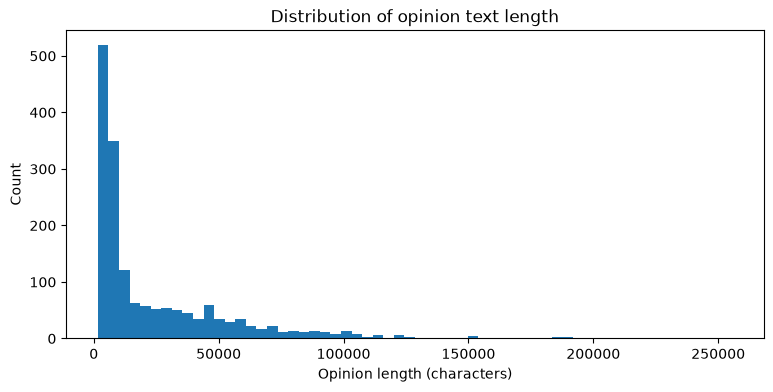

In [4]:
print(df["text_len"].describe())

fig, ax = plt.subplots()
ax.hist(df["text_len"], bins=60)
ax.set_xlabel("Opinion length (characters)")
ax.set_ylabel("Count")
ax.set_title("Distribution of opinion text length")
plt.show()

In [5]:
outliers = df.nlargest(5, "text_len")[["id", "case_name", "text_len"]]
print("5 longest opinions (sanity-check these aren't garbage/duplicated text):")
outliers

5 longest opinions (sanity-check these aren't garbage/duplicated text):


,id,case_name,text_len
473,4549553,Yassir Fazaga v. Fbi,255510
667,3032002,Menotti v. City of Seattle,235081
1448,3052526,Navajo Nation v. Usfs,202891
710,3065072,Al-Kidd v. Ashcroft,193376
184,10626922,Al Otro Lado v. Alejandro Mayorkas,191529


## 4. Data quality checks

Encoding artifacts, OCR flags, and anything that could break downstream
chunking/embedding.

In [6]:
mangled = df[df["plain_text"].str.contains("\ufffd", regex=False, na=False)]
print(f"Opinions containing the U+FFFD replacement character (real encoding corruption): {len(mangled)}")
if len(mangled):
    display(mangled[["id", "case_name"]])

ocr_flagged = df[~df["extracted_by_ocr"].isin(["", "f", "F", "false", "False", "0"])]
print(f"Opinions flagged as OCR-extracted: {len(ocr_flagged)}")

print()
print("Opinion 'type' breakdown (CourtListener internal codes):")
print(df["type"].value_counts())

Opinions containing the U+FFFD replacement character (real encoding corruption): 1


,id,case_name
1428,10754453,"The Ohio House, LLC v. City of Costa Mesa"


Opinions flagged as OCR-extracted: 1

Opinion 'type' breakdown (CourtListener internal codes):
type
010combined    1696
Name: count, dtype: int64


## 5. Opinions over time

Checking for coverage gaps across the 2005-2025 window.

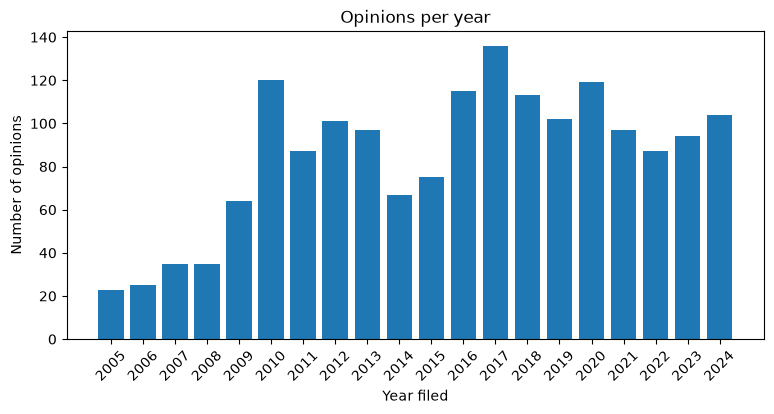

In [7]:
year_counts = df["year"].value_counts().sort_index()

fig, ax = plt.subplots()
ax.bar(year_counts.index, year_counts.values)
ax.set_xlabel("Year filed")
ax.set_ylabel("Number of opinions")
ax.set_title("Opinions per year")
plt.xticks(rotation=45)
plt.show()

## 6. Precedential status

Published opinions carry precedential weight; unpublished ones generally don't — relevant later for how much weight retrieval/generation should give a hit.

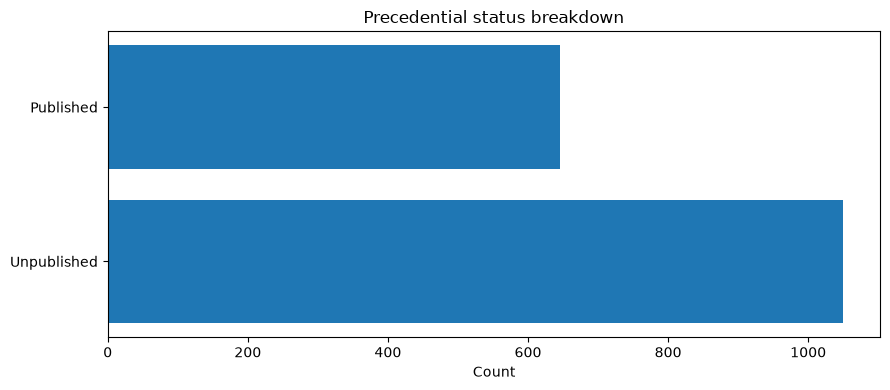

precedential_status
Unpublished    1050
Published       646
Name: count, dtype: int64

In [8]:
status_counts = df["precedential_status"].value_counts()
fig, ax = plt.subplots()
ax.barh(status_counts.index, status_counts.values)
ax.set_xlabel("Count")
ax.set_title("Precedential status breakdown")
plt.tight_layout()
plt.show()
status_counts

## 7. Random sample viewer

Read a few actual opinions yourself — re-run this cell for a different
random sample.

In [9]:
sample = df.sample(5)
for _, row in sample.iterrows():
    print(f"=== {row['case_name']}  ({row['date_filed']}, id={row['id']}) ===")
    print(row["plain_text"][:500].replace(chr(10), " "))
    print()

=== Frederick Cooley v. R. McNabb  (2010-03-30, id=3035749) ===
                                                                           FILED                              NOT FOR PUBLICATION                            MAR 30 2010                                                                          MOLLY C. DWYER, CLERK                       UNITED STATES COURT OF APPEALS                     U .S. C O U R T OF APPE ALS                                  FOR THE NINTH CIRCUIT     FREDERICK MARC COOLEY,                          No. 09-15719                

=== Ahmad Arian v. City of Los Angeles  (2015-11-16, id=3155052) ===
                                                                            FILED                            NOT FOR PUBLICATION                              NOV 16 2015                                                                           MOLLY C. DWYER, CLERK                     UNITED STATES COURT OF APPEALS                        U.S. COURT OF APPEALS    

## 8. Citation graph structure

Nodes = opinions (internal = one of our 1,696; external = outside the
ingested set, referenced only because it cites or is cited by one of ours).
Edges = citing -> cited.

In [10]:
G = nx.read_graphml(config.GRAPH_PATH)
internal = [n for n, d in G.nodes(data=True) if d["is_external"] == 0]
external = [n for n, d in G.nodes(data=True) if d["is_external"] == 1]

print(f"Total nodes: {G.number_of_nodes()}  (internal: {len(internal)}, external stubs: {len(external)})")
print(f"Total edges: {G.number_of_edges()}")

int_int = sum(1 for u, v in G.edges if G.nodes[u]["is_external"] == 0 and G.nodes[v]["is_external"] == 0)
int_ext = sum(1 for u, v in G.edges if G.nodes[u]["is_external"] == 0 and G.nodes[v]["is_external"] == 1)
ext_int = sum(1 for u, v in G.edges if G.nodes[u]["is_external"] == 1 and G.nodes[v]["is_external"] == 0)
print(f"internal -> internal: {int_int}")
print(f"internal -> external: {int_ext}")
print(f"external -> internal: {ext_int}")

Total nodes: 26594  (internal: 1696, external stubs: 24898)
Total edges: 56113
internal -> internal: 2103
internal -> external: 29795
external -> internal: 24215


### Degree distribution

Citation networks are typically power-law shaped: a few landmark cases get cited constantly, most rarely. Log scale makes that visible.

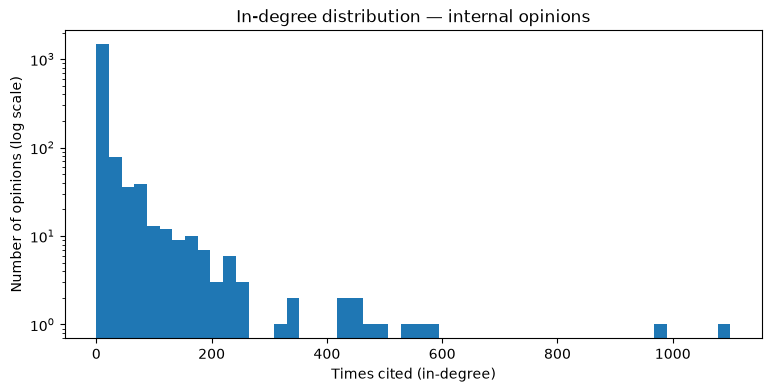

Median in-degree: 0.0
Max in-degree: 1100


In [11]:
in_deg = [G.in_degree(n) for n in internal]

fig, ax = plt.subplots()
ax.hist(in_deg, bins=50)
ax.set_yscale("log")
ax.set_xlabel("Times cited (in-degree)")
ax.set_ylabel("Number of opinions (log scale)")
ax.set_title("In-degree distribution — internal opinions")
plt.show()

print(f"Median in-degree: {statistics.median(in_deg)}")
print(f"Max in-degree: {max(in_deg)}")

### Most-cited cases (hubs)

In [12]:
top_cited = sorted(internal, key=lambda n: G.in_degree(n), reverse=True)[:15]
pd.DataFrame([
    {"case_name": G.nodes[n]["case_name"], "date_filed": G.nodes[n]["date_filed"], "times_cited": G.in_degree(n)}
    for n in top_cited
])

,case_name,date_filed,times_cited
0,Mary Gordon v. County of Orange,2018-04-30,1100
1,"Laurie Tsao v. Desert Palace, Inc.",2012-10-23,980
2,Ellen Keates v. Michael Koile,2018-03-06,572
3,John Crowley v. Bruce Bannister,2013-10-30,550
4,Marsh v. County of San Diego,2012-05-29,544
5,John Benavidez v. County of San Diego,2021-04-12,494
6,Morgan v. Morgensen,2006-10-06,478
7,Heriberto Rodriguez v. County of Los Angeles,2018-05-30,457
8,Edward Furnace v. Paul Sullivan,2013-01-17,456
9,Clarence Jones v. Max Williams,2015-06-26,422


### Isolated cases

Internal opinions with zero citation connections at all — worth knowing which ones, since they'll never surface via graph expansion in retrieval.

In [13]:
isolated = [n for n in internal if G.in_degree(n) == 0 and G.out_degree(n) == 0]
print(f"{len(isolated)} isolated internal opinions:")
for n in isolated:
    print(f"  {G.nodes[n]['case_name']}  ({G.nodes[n]['date_filed']})")

3 isolated internal opinions:
  Joy Scherer v. City of Los Angeles  (2024-11-04)
  Maffeo v. Nevada Ex Rel. Board of Regents of the Nevada System of Higher Education  (2011-12-15)
  James Thomas v. Everett Carroll  (2010-12-22)


### Drawing the graph itself

The full graph (26,594 nodes) would just render as an unreadable blob, so
two more targeted views instead:

1. **The core network** -- the ~60 most-connected internal cases and the
   citation links directly between them, i.e. the backbone of this corpus.
2. **One case's actual neighborhood** -- zoom into a single case and draw
   everything citing it or cited by it, colored by the treatment label from
   the classifier. This is essentially what "graph expansion" in hybrid
   retrieval (TECH_DESIGN.md module 3) will walk at query time.

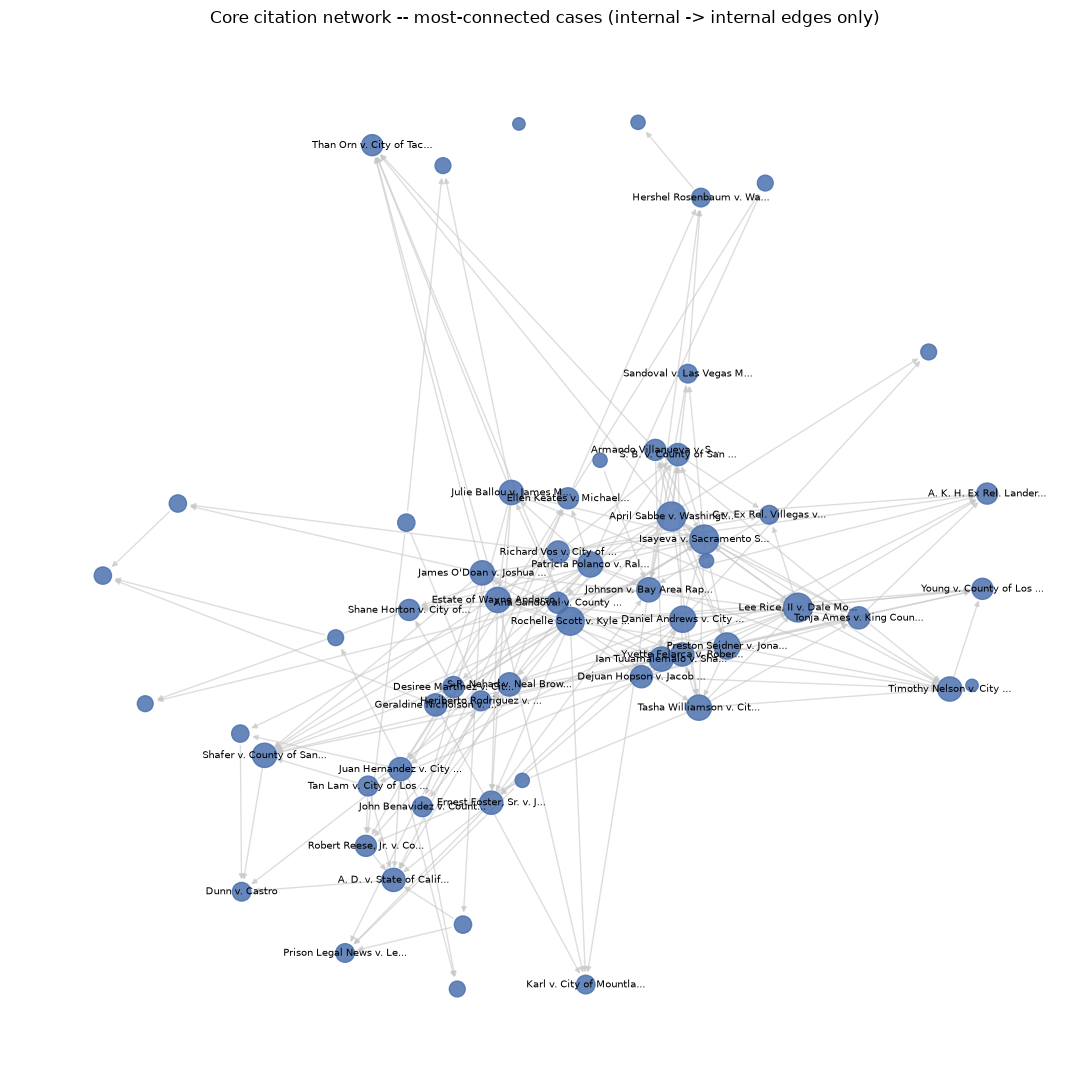

Node size = how connected within this core; edge color = classified treatment (see legend below).


In [14]:
TREATMENT_COLORS = {
    "overruled": "#d62728",
    "distinguished": "#ff7f0e",
    "followed": "#2ca02c",
    "neutral_cite": "#c7c7c7",
    "not_located": "#c7c7c7",
    "no_reporter_citation": "#c7c7c7",
}

def short_name(case_name, n=28):
    return case_name if len(case_name) <= n else case_name[: n - 1] + "..."

int_int_edges = [
    (u, v) for u, v in G.edges
    if G.nodes[u]["is_external"] == 0 and G.nodes[v]["is_external"] == 0
]
H = G.edge_subgraph(int_int_edges).copy()

core_nodes = sorted(H.degree, key=lambda kv: kv[1], reverse=True)[:60]
core_nodes = [n for n, _ in core_nodes]
H_core = H.subgraph(core_nodes).copy()

pos = nx.spring_layout(H_core, k=0.6, seed=42, iterations=100)
fig, ax = plt.subplots(figsize=(11, 11))

node_sizes = [80 + 25 * H_core.degree(n) for n in H_core.nodes]
nx.draw_networkx_nodes(H_core, pos, node_size=node_sizes, node_color="#4c72b0", alpha=0.85, ax=ax)

edge_colors = [TREATMENT_COLORS.get(H_core[u][v]["treatment"], "#c7c7c7") for u, v in H_core.edges]
nx.draw_networkx_edges(H_core, pos, edge_color=edge_colors, alpha=0.6, arrows=True, arrowsize=8, ax=ax)

labels = {n: short_name(G.nodes[n]["case_name"], 24) for n in H_core.nodes if H_core.degree(n) >= 4}
nx.draw_networkx_labels(H_core, pos, labels, font_size=7, ax=ax)

ax.set_title("Core citation network -- most-connected cases (internal -> internal edges only)")
ax.axis("off")
plt.tight_layout()
plt.show()
print("Node size = how connected within this core; edge color = classified treatment (see legend below).")

**Edge colors**: red = overruled, orange = distinguished, green = followed, gray = neutral/unclassified -- same as the treatment-classifier bar chart in section 9 below.

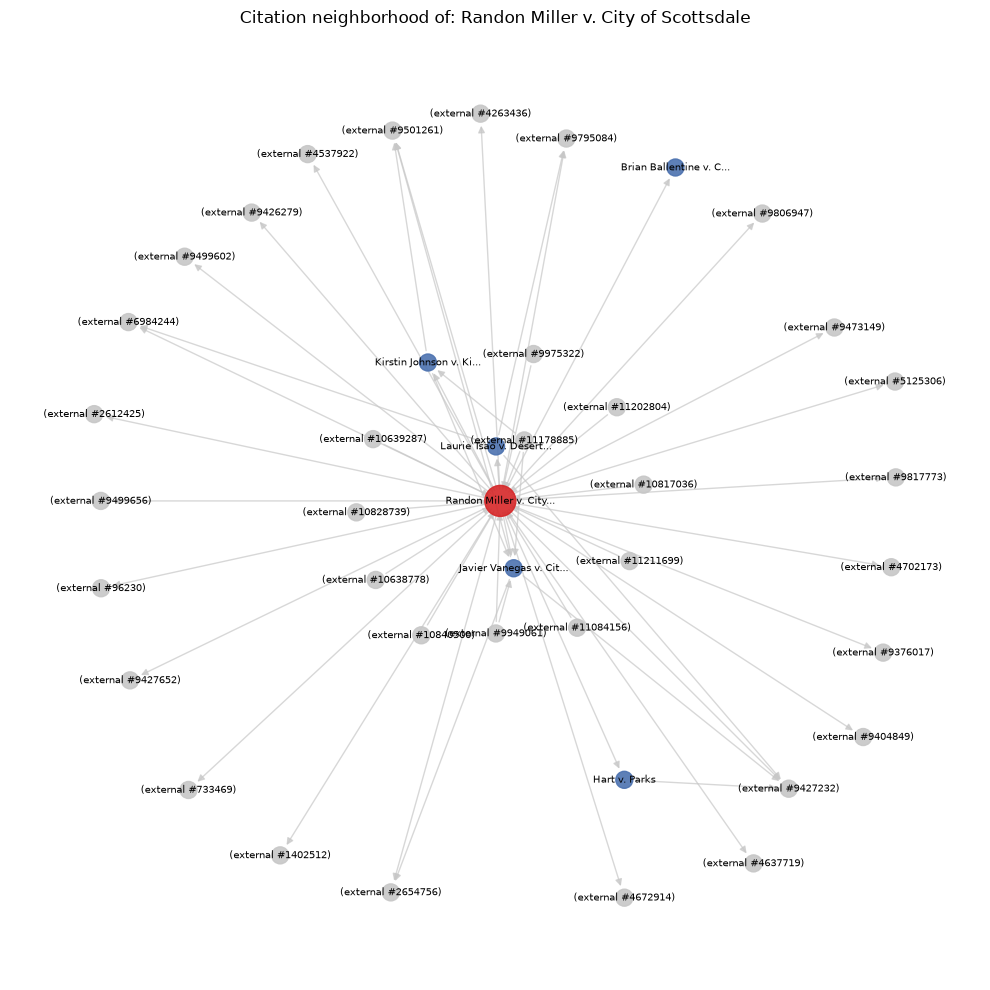

Target: Randon Miller v. City of Scottsdale  (2023-12-08)
Red node = the target case. Blue = other internal (ingested) cases. Gray nodes = external (outside our 1,696-opinion scope, metadata-only -- this is where 'has this been overruled by something we did not ingest' checks would need a live lookup).


In [15]:
# Pick one case to zoom into: the most-cited case whose FULL neighborhood
# (including external citers) is still small enough to actually read.
# Change TARGET_CASE_ID to explore a different one -- any id from the
# "most-cited cases" table above works, just note the bigger hubs
# (e.g. Mary Gordon, cited 1100 times) will be unreadably dense.
by_manageable_degree = sorted(
    internal, key=lambda n: G.in_degree(n) + G.out_degree(n), reverse=True
)
TARGET_CASE_ID = next(n for n in by_manageable_degree if G.in_degree(n) + G.out_degree(n) <= 40)

neighbors = set(G.predecessors(TARGET_CASE_ID)) | set(G.successors(TARGET_CASE_ID))
ego_nodes = neighbors | {TARGET_CASE_ID}
E = G.subgraph(ego_nodes).copy()

pos = nx.spring_layout(E, k=0.9, seed=7, iterations=100)
fig, ax = plt.subplots(figsize=(10, 10))

node_colors = ["#d62728" if n == TARGET_CASE_ID else ("#4c72b0" if G.nodes[n]["is_external"] == 0 else "#c7c7c7")
               for n in E.nodes]
node_sizes = [500 if n == TARGET_CASE_ID else 150 for n in E.nodes]
nx.draw_networkx_nodes(E, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9, ax=ax)

edge_colors = [TREATMENT_COLORS.get(E[u][v]["treatment"], "#c7c7c7") for u, v in E.edges]
nx.draw_networkx_edges(E, pos, edge_color=edge_colors, alpha=0.7, arrows=True, arrowsize=10, ax=ax)

labels = {
    n: short_name(G.nodes[n]["case_name"] if G.nodes[n]["case_name"] else f"(external #{n})", 22)
    for n in E.nodes
}
nx.draw_networkx_labels(E, pos, labels, font_size=7, ax=ax)

ax.set_title(f"Citation neighborhood of: {G.nodes[TARGET_CASE_ID]['case_name']}")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Target: {G.nodes[TARGET_CASE_ID]['case_name']}  ({G.nodes[TARGET_CASE_ID]['date_filed']})")
print("Red node = the target case. Blue = other internal (ingested) cases. Gray nodes = external "
      "(outside our 1,696-opinion scope, metadata-only -- this is where 'has this been overruled by "
      "something we did not ingest' checks would need a live lookup).")

## 9. Treatment classification results

From `citations/classify_treatment.py` — the rule-based first pass, scoped
to internal->internal edges only (the only ones with text on both ends).
Hand-validated separately; see project notes on why this is a rough signal,
not a final answer.

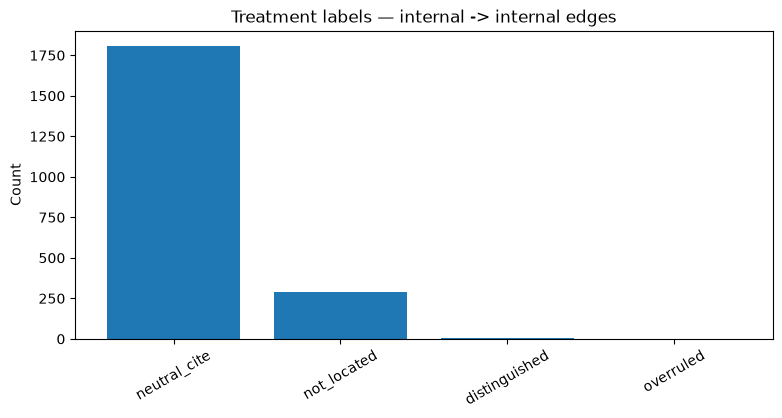

Counter({'neutral_cite': 1810,
         'not_located': 289,
         'distinguished': 3,
         'overruled': 1})

In [16]:
treatment_counts = Counter(
    data["treatment"] for u, v, data in G.edges(data=True)
    if G.nodes[u]["is_external"] == 0 and G.nodes[v]["is_external"] == 0
)
fig, ax = plt.subplots()
labels, values = zip(*sorted(treatment_counts.items(), key=lambda kv: -kv[1]))
ax.bar(labels, values)
ax.set_ylabel("Count")
ax.set_title("Treatment labels — internal -> internal edges")
plt.xticks(rotation=30)
plt.show()
treatment_counts

## 10. Doctrine relevance sanity check

All opinions matched on "qualified immunity" (the loose filter). How many
also touch the original narrower scope (excessive force / 4th Amendment)?

In [17]:
text_lower = df["plain_text"].str.lower()
has_ef = text_lower.str.contains("excessive force", regex=False)
has_4th = text_lower.str.contains("fourth amendment", regex=False)

print(f"Contains 'excessive force': {has_ef.sum()} ({has_ef.mean():.0%})")
print(f"Contains 'fourth amendment': {has_4th.sum()} ({has_4th.mean():.0%})")
print(f"Contains either (= old strict-filter scope): {(has_ef | has_4th).sum()}")
print(f"Qualified-immunity-only, neither of the above (new in the loose scope): {(~(has_ef | has_4th)).sum()}")

Contains 'excessive force': 508 (30%)
Contains 'fourth amendment': 703 (41%)
Contains either (= old strict-filter scope): 839
Qualified-immunity-only, neither of the above (new in the loose scope): 857


## Summary

- **No structural problems**: no empty/duplicate opinions, only 1 real
  encoding-corrupted opinion and 1 OCR-extracted opinion out of 1,696.
- **Text length**: median ~9,700 characters; a handful of 200k+ char
  opinions, verified legitimate (e.g. *Fazaga v. FBI*), not garbage.
- **Time coverage**: even spread 2005-2024, no gaps.
- **Citation graph**: normal power-law shape, only 3 fully isolated
  opinions, 56,113 total edges (2,103 internal-to-internal, the rest touch
  cases outside our narrow scope — expected and useful for precedent-currency
  checks later).
- **Treatment classification**: still a rough signal, not a trustworthy
  final answer — see the classifier's own validation notes. Plan is to
  defer precise treatment-checking to query time via an LLM, on just the
  cases that actually appear in a generated answer.

Next step in the build order: chunking + embeddings for retrieval
(TECH_DESIGN.md module 3).